In [2]:
#Bibliotecas
import pandas as pd
import polars as pl
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import re
import math

In [3]:
# Lista para alocar os dados da contagem de partículas
particulas = []

# Função para contar a quantidade de partículas em cada linha TRIG
def contar_particulas(evento):
    contagem = {}
    for linha in evento:
        partes = linha.split()
        if partes[0].startswith("TRIG"):
            contagem[partes[0]] = len(partes) - 1  
    return contagem

# Função para processar o arquivo e contar as partículas em cada evento
def contar_particulas_em_eventos(nome_arquivo):
    with open(nome_arquivo, 'r') as arquivo:
        linhas = arquivo.readlines()
    
    eventos = []
    evento_atual = []
    
    for linha in linhas:
        if linha.startswith("EVTE"):
            eventos.append(evento_atual)
            evento_atual = []
        evento_atual.append(linha)
    
    # Contagem da quantidade de partículas em cada linha TRIG em cada evento
    for i, evento in enumerate(eventos):
        contagem = contar_particulas(evento)
        #print(f"Evento {i + 1}:")
        for linha_trig, quantidade in contagem.items():
            #print(f"{linha_trig}: {quantidade} partículas")
            particulas.append(contagem)

if __name__ == "__main__":
    arquivo = "proton1E15"  
    contar_particulas_em_eventos(arquivo)


In [4]:
x1 = [0,346]
x2 = [-400,-346]
x3 = [400,-346]

r1 = (x1[0]**2+x1[1]**2)**0.5
r2 = (x2[0]**2+x2[1]**2)**0.5
r3 = (x3[0]**2+x3[1]**2)**0.5

trig1 = []
trig2 = []
trig3 = []

#type(particulas[20])

In [5]:
trigs = []
for i in particulas:
    trigs_aux = list(i.values())
    trigs.append(trigs_aux)

In [6]:
for i in range(0,len(trigs),3):
    sublista = trigs[i]
    trig1.append(sublista[0])

In [7]:
for i in range(0,len(trigs),3):
    sublista = trigs[i]
    trig2.append(sublista[1])

In [8]:
for i in range(0,len(trigs),3):
    sublista = trigs[i]
    trig3.append(sublista[2])

In [9]:
print(trig1,'\n',
      trig2,'\n',
      trig3)

[53, 42, 42, 24, 133, 12, 19, 55, 43, 24, 322, 12, 512, 15, 278, 338, 25, 74, 21, 32, 24, 220, 129, 115, 79, 14, 85, 59, 31, 41, 46, 65, 59, 45, 27, 42, 16, 13, 32, 50, 132, 175, 18, 335, 117, 24, 27, 90, 126, 18, 91, 37, 27, 163, 93, 142, 9, 32, 19, 33, 23, 9, 120, 63, 21, 582, 21, 246, 30, 51, 137, 53, 23, 18, 126, 36, 53, 72, 12, 92, 43, 33, 113, 24, 152, 5, 20, 74, 24, 50, 8, 36, 28, 8, 3, 95, 12, 41, 24, 65] 
 [50, 38, 19, 22, 102, 9, 13, 40, 26, 26, 209, 16, 314, 7, 202, 178, 18, 58, 13, 22, 24, 146, 65, 62, 60, 9, 94, 45, 18, 13, 19, 49, 44, 36, 21, 37, 15, 9, 28, 26, 101, 118, 22, 226, 51, 17, 18, 40, 93, 12, 60, 35, 7, 94, 51, 145, 14, 21, 8, 43, 16, 15, 95, 38, 14, 403, 8, 201, 20, 27, 58, 24, 31, 10, 108, 16, 30, 55, 8, 61, 26, 13, 68, 6, 94, 0, 23, 33, 11, 32, 10, 26, 13, 4, 3, 52, 8, 22, 25, 34] 
 [58, 38, 25, 14, 75, 12, 13, 35, 22, 19, 220, 20, 353, 12, 198, 227, 19, 58, 40, 24, 26, 134, 117, 64, 64, 11, 71, 43, 13, 19, 17, 49, 29, 41, 33, 46, 11, 3, 44, 23, 80, 121, 7, 

In [10]:
x_b = []
y_b = []

for i in range(len(trig1)):
        numerator = (trig1[i]*x1[0]+trig2[i]*x2[0]+trig3[i]*x3[0])
        demoninator = (trig1[i]+trig2[i]+trig3[i])
        numerator1 = (trig1[i]*x1[1]+trig2[i]*x2[1]+trig3[i]*x3[1])

        if demoninator == 0:
                x_b.append(0)
                y_b.append(0)
        else:
                x_b.append(numerator/demoninator)
                y_b.append(numerator1/demoninator)


In [11]:
data = {
    'x_b':x_b,
    'y_b':y_b,
    'trig1':trig1,
    'trig2':trig2,
    'trig3':trig3
}

df = pl.DataFrame(data)

df = df.with_columns(
    [
        ((df['x_b']**2+df['y_b']**2)**0.5).alias('r_b'),
        (pl.col('trig1')/(math.pi*65**2)).alias('rho1'),
        (pl.col('trig2')/(math.pi*65**2)).alias('rho2'),
        (pl.col('trig3')/(math.pi*65**2)).alias('rho3')
    ]
)

df = df.with_columns(
    [
        (((x1[0]-df['x_b'])**2 + (x1[1]-df['y_b'])**2)**0.5).alias('r1_b'),
        (((x2[0]-df['x_b'])**2 + (x2[1]-df['y_b'])**2)**0.5).alias('r2_b'),
        (((x3[0]-df['x_b'])**2 + (x3[1]-df['y_b'])**2)**0.5).alias('r3_b'),
    ]
)



df2 = df.mean()
df2

x_b,y_b,trig1,trig2,trig3,r_b,rho1,rho2,rho3,r1_b,r2_b,r3_b
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
3.049054,-51.365054,76.22,51.19,51.96,74.179031,0.005742,0.003857,0.003915,399.546669,501.870376,496.854233


In [28]:
rho = [
    df2['rho1'][0],
    df2['rho2'][0],
    df2['rho3'][0]
]

r_b = [
    df2['r1_b'][0],
    df2['r2_b'][0],
    df2['r3_b'][0]
]
print(rho,r_b)


data2 = {
    'rho':rho,
    'r_b':r_b
}

df3 = pl.DataFrame(data2)

[0.0057423856863736125, 0.003856635047041005, 0.003914646552925387] [399.54666916119453, 501.87037628915436, 496.85423297294335]


In [12]:
def formatar_string(s):
   
    match = re.match(r'([a-zA-Z]+)([0-9]+(?:\.[0-9]+)?[Ee][0-9]+)', s)

    if match:
        
        palavra = match.group(1).capitalize()
        numero = match.group(2)

        return f'{palavra} {numero}'
    else:
        return s

name = formatar_string(arquivo)
name

'Proton 1E15'

[0.0057423856863736125, 0.003856635047041005, 0.003914646552925387] [399.54666916119453, 501.87037628915436, 496.85423297294335]


/tmp/ipykernel_6215/2003956595.py:32: RuntimeWarning: invalid value encountered in power
  return np.array(((c/r0**2)*(x/r0)**(-a)*(1+x/r0)**(-b)))
/home/orfei/.local/lib/python3.10/site-packages/scipy/optimize/_minpack_py.py:906: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


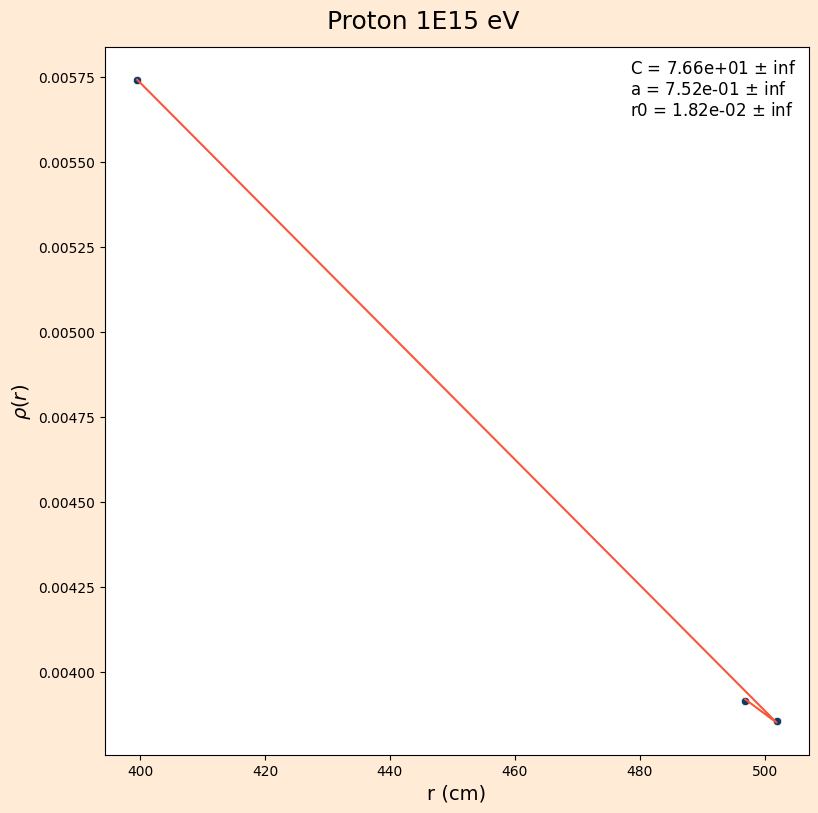

In [13]:
# Essa modelagem não está certa!

fig, ax = plt.subplots(1, 1, figsize = (8, 8), facecolor = '#FFEBD6')
fig.suptitle(str(name) + ' eV', size = 18)
sns.scatterplot(x = r_b, y = rho, ax = ax, color = '#0D3B66')
fig.tight_layout()

ax.set_xlabel('r (cm)', size = 14)
ax.set_ylabel(r'$\rho(r)$', size = 14)

#ax.set_xlim(xmin=0)
#ax.set_ylim(ymin=0)

# Como b varia pouco, vou deixá-lo constante
b = 1
p0 = (10,1,300)
def f_model(x, c, a, r0):
    return np.array(((c/r0**2)*(x/r0)**(-a)*(1+x/r0)**(-b)))

popt, pcov = curve_fit(
    f=f_model,       
    xdata=r_b,   
    ydata=rho,   
    p0=p0,
    maxfev = 2000000
    #sigma=df["Dy"]   
)
c_opt, a_opt, r0_opt = popt

inc = np.sqrt(np.diag(pcov))

y = f_model(r_b,c_opt, a_opt, r0_opt)

plt.plot(r_b, y, color = '#F95738')

ax.legend(title = 'C = {:.2e} $\pm$ {:.2e}\na = {:.2e} $\pm$ {:.2e}\nr0 = {:.2e} $\pm$ {:.2e}'
          .format(c_opt,inc[0],a_opt,inc[1],r0_opt,inc[2]),
          title_fontsize = 12, facecolor = 'white', frameon = False)

plt.savefig('plots/fit_' + str(arquivo) + '.png',bbox_inches = 'tight')

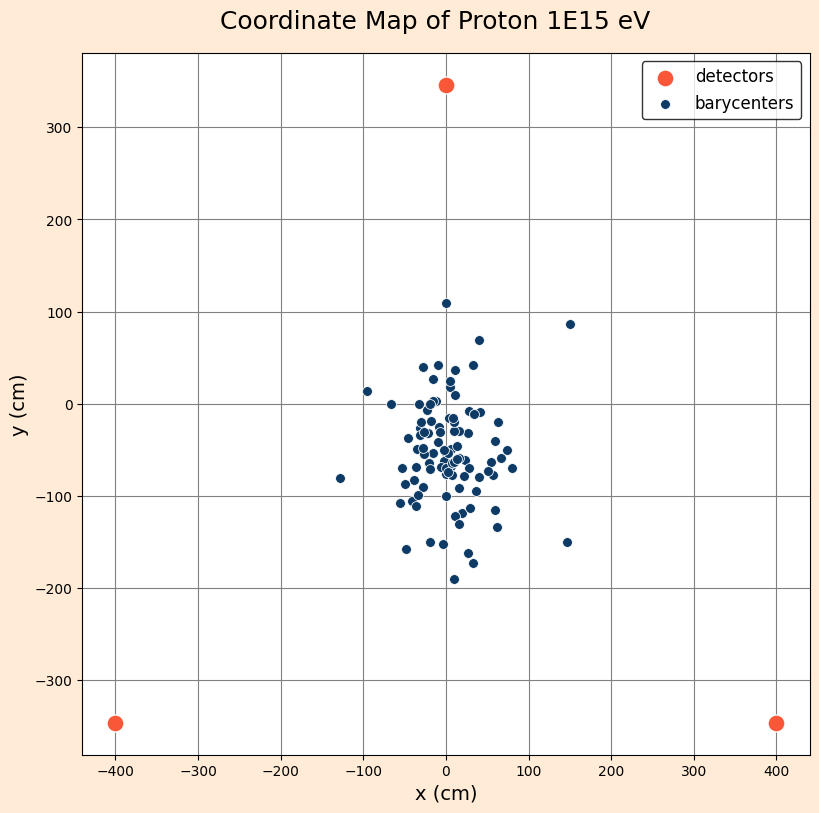

In [14]:
fig, ax = plt.subplots(1, 1, figsize = (8, 8), facecolor = '#FFEBD6')
fig.suptitle('Coordinate Map of ' + str(name) + ' eV', size = 18)
fig.tight_layout()
ax.set_axisbelow(True)
ax.yaxis.grid(color='gray', linestyle='-')
ax.xaxis.grid(color='gray', linestyle='-')

sns.scatterplot(x = [x1[0],x2[0],x3[0]], y = [x1[1],x2[1],x3[1]], ax = ax, color = '#F95738', s = 150)
sns.scatterplot(x = df['x_b'], y = df['y_b'], ax = ax, color = '#0D3B66',s = 50)

ax.set_xlabel('x (cm)', size = 14)
ax.set_ylabel('y (cm)', size = 14)


ax.legend(['detectors', 'barycenters'], edgecolor = 'black', fontsize = 12, loc = 1)

plt.savefig('plots/map_' + str(arquivo) + '.png',bbox_inches = 'tight')

In [15]:
# Comparação do número de partículas no tanque com a distribuição lateral do Corsika com r = 346 cm

Energy = {'1E13':0,'1E14':1, '2.15E14':2, '4.64E14':3,'1E15':4,'2.15E15':5,'4.64E15':6}
Particle = ['Photon','Proton','Iron']
radius = 65
N_tanque = []

rho_photon = [3.77691e-06,0.000124827, 0.000601522, 0.00155853,0.00552918,0.0168817,0.0541952]
rho_proton = [8.32333e-06,0.000198282, 0.000696983, 0.00154504,0.00568147,0.0121761,0.0342564]
rho_iron = [0,9.83903e-06, 4.31253e-05, 0.000181546,0.000857134,0.00266104,0.00917539]

print(name.split()[0])
print(name.split()[1])

print(Energy.get(name.split()[1]))
aux = Energy.get(name.split()[1])


if name.split()[0] == 'Photon':
        N_tanque = rho_photon[aux]*math.pi*radius**2
elif name.split()[0] == 'Proton':
        N_tanque = rho_proton[aux]*math.pi*radius**2
elif name.split()[0] == 'Iron':
        N_tanque = rho_iron[aux]*math.pi*radius**2

N_1 = df2['rho1'][0]*math.pi*65**2
N_2 = df2['rho2'][0]*math.pi*65**2
N_3 = df2['rho3'][0]*math.pi*65**2


print('Número de partículas em cada tanque:', N_tanque,
       '\nNúmero de partículas no tanque 1:', N_1,
       '\nNúmero de partículas no tanque 2:', N_2,
       '\nNúmero de partículas no tanque 3:', N_3)

data = {'Particle': [name.split()[0]],
         'Energy': [name.split()[1]],
         'N_detector': [N_tanque],
          'N_det_1': [N_1],
         'N_det_2': [N_2], 
         'N_det_3': [N_3]}

#df = pd.DataFrame(data)

#df.to_csv('particles_detectors.csv', index = False)
#df.to_csv('particles_detectors.csv', mode = 'a', index = False, header = False)

Proton
1E15
4
Número de partículas em cada tanque: 75.41145214742114 
Número de partículas no tanque 1: 76.21999999999996 
Número de partículas no tanque 2: 51.190000000000005 
Número de partículas no tanque 3: 51.95999999999999


In [16]:
df = pd.read_csv('particles_detectors.csv')
df

,Particle,Energy,N_detector,N_det_1,N_det_2,N_det_3
0,Photon,1.000000e+13,0.050132,0.04,0.06,0.05
1,Photon,1.000000e+14,1.656857,1.52,1.34,1.34
2,Photon,2.150000e+14,7.984139,8.62,6.42,5.37
3,Photon,4.640000e+14,20.686726,21.25,14.21,14.35
4,Photon,1.000000e+15,73.390072,73.88,51.52,50.68
5,Photon,2.150000e+15,224.074669,220.40,151.31,151.52
6,Photon,4.640000e+15,719.345298,730.31,475.66,477.82
7,Proton,1.000000e+13,0.110477,0.11,0.05,0.02
8,Proton,1.000000e+14,2.631842,2.66,2.03,2.17
9,Proton,2.150000e+14,9.251215,8.86,6.19,6.39


In [17]:
print(c_opt)

76.58109569097172


In [18]:
# Reconstrução da energia

# Parâmetros fóton

k_photon = 2.56E-19 #+- 8.80E-19
p_photon = 1.47 #+- 0.10

# Parâmetros próton

k_proton = 1.04E-11
p_proton = 1.19

# Parâmetros ferro

k_iron = 3.09E-11
p_iron = 1.14

if name.split()[0] == 'Photon':
        E = (c_opt/k_photon)**(1/p_photon)
elif name.split()[0] == 'Proton':
        E = (c_opt/k_proton)**(1/p_proton)
elif name.split()[0] == 'Iron':
        E = (c_opt/k_iron)**(1/p_iron)

print('{:e}'.format(E))


6.496496e+10


In [32]:
df3.write_csv('bary_dat/' + arquivo + '_bary.csv', separator= '\t', has_header= False)